In [17]:
import torch
import torch.nn as nn
import torchvision.transforms as Transforms
from torch.utils.data import Dataset,DataLoader
import matplotlib.pyplot as plt
from PIL import Image
import os

In [18]:
device = torch.device("mps" if torch.mps.is_available() else "cpu")
print(device)

mps


In [19]:
my_transform = Transforms.Compose([
    Transforms.Resize((256,256)),
    Transforms.ToTensor(),
    Transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)),
    
])

In [20]:
#pwecwptual loss:

import torchvision.models as model

class VGGPerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()

        

In [21]:
#from google.colab import drive
#drive.mount('/content/drive')

In [22]:
img_directory = 'Dataset/Dogs/archive-2/images/images/n02085620-Chihuahua'

In [23]:
class CustomDataset(Dataset):

  def __init__(self,img_dir,transform):

    self.img_dir = img_dir
    self.transform = my_transform
    self.files = os.listdir(self.img_dir)

  def __len__(self):

    return len(self.files)

  def __getitem__(self,index):

    img_path = os.path.join(self.img_dir,self.files[index])

    image = Image.open(img_path).convert("RGB")

    image = self.transform(image)

    return image


In [24]:
train_dataset = CustomDataset(img_directory,transform=my_transform)

In [25]:
train_dataloader = DataLoader(train_dataset,batch_size = 64, shuffle = True)

In [26]:
def add_noise(x,factor=0.1):
  noisy =  x + torch.randn_like(x) * factor
  return torch.clamp(noisy,-1,1)

In [27]:
class DAE(nn.Module):
  def __init__(self):
    super().__init__()

    self.encoder = nn.Sequential(
        nn.Conv2d(in_channels=3,out_channels=16,kernel_size=3,stride=1,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=4,stride=4,padding=0),
        nn.Conv2d(in_channels=16,out_channels=32,kernel_size=3,stride=1,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=4,stride=4,padding=0),
        nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,stride=1,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2,padding=0)
    )
    
    
    self.decoder = nn.Sequential(
        nn.ConvTranspose2d(in_channels=64,out_channels=32,kernel_size=2,stride=2,padding=0),
        nn.ReLU(),
        nn.ConvTranspose2d(in_channels=32,out_channels=16,kernel_size=4,stride=4,padding=0),
        nn.ReLU(),
        nn.ConvTranspose2d(in_channels=16,out_channels=3,kernel_size=4,stride=4,padding=0),
        nn.ReLU()
    )

  def forward(self,x):
    #x = x.view(x.size(0),-1)

    x = self.encoder(x)

    x = self.decoder(x)

    return x



In [28]:
class DAE_2(nn.Module):
  def __init__(self):
    super().__init__()

    self.encoder = nn.Sequential(
        nn.Conv2d(3, 32, 3, stride=2, padding=1), # 128x128
        nn.ReLU(),
        nn.Conv2d(32, 64, 3, stride=2, padding=1), # 64x64
        nn.ReLU(),
        nn.Conv2d(64, 128, 3, stride=2, padding=1), # 32x32
        nn.ReLU(),
)

    self.decoder = nn.Sequential(
        nn.ConvTranspose2d(128,64,3,stride=2,padding=1,output_padding=1),
        nn.ReLU(),
        nn.ConvTranspose2d(64,32,3,stride=2,padding=1,output_padding=1),
        nn.ReLU(),
        nn.ConvTranspose2d(32,3,3,stride=2,padding=1,output_padding=1),
        nn.Tanh()
)

  def forward(self,x):
    #x = x.view(x.size(0),-1)

    x = self.encoder(x)

    x = self.decoder(x)

    return x



In [29]:
model = DAE_2()
model.to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)


In [30]:
num_epochs = 1000

In [31]:
for epoch in range(num_epochs):

  model.train()
  total_loss = 0


  for images in train_dataloader:
    images = images.to(device)
    noise_image = add_noise(images)

    output = model(noise_image)

    loss  = criterion(output,images)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    total_loss = loss.item()

  print(f"Epoch {epoch+1}/{num_epochs}  Loss: {total_loss/len(train_dataloader):.4f}")




Epoch 1/1000  Loss: 0.0809
Epoch 2/1000  Loss: 0.0848
Epoch 3/1000  Loss: 0.0744
Epoch 4/1000  Loss: 0.0580
Epoch 5/1000  Loss: 0.0390
Epoch 6/1000  Loss: 0.0273
Epoch 7/1000  Loss: 0.0249
Epoch 8/1000  Loss: 0.0229
Epoch 9/1000  Loss: 0.0237
Epoch 10/1000  Loss: 0.0199
Epoch 11/1000  Loss: 0.0192
Epoch 12/1000  Loss: 0.0180
Epoch 13/1000  Loss: 0.0184
Epoch 14/1000  Loss: 0.0220
Epoch 15/1000  Loss: 0.0163
Epoch 16/1000  Loss: 0.0190
Epoch 17/1000  Loss: 0.0123
Epoch 18/1000  Loss: 0.0121
Epoch 19/1000  Loss: 0.0152
Epoch 20/1000  Loss: 0.0128
Epoch 21/1000  Loss: 0.0185
Epoch 22/1000  Loss: 0.0103
Epoch 23/1000  Loss: 0.0107
Epoch 24/1000  Loss: 0.0097
Epoch 25/1000  Loss: 0.0158
Epoch 26/1000  Loss: 0.0088
Epoch 27/1000  Loss: 0.0097
Epoch 28/1000  Loss: 0.0070
Epoch 29/1000  Loss: 0.0094
Epoch 30/1000  Loss: 0.0109
Epoch 31/1000  Loss: 0.0112
Epoch 32/1000  Loss: 0.0114
Epoch 33/1000  Loss: 0.0103
Epoch 34/1000  Loss: 0.0082
Epoch 35/1000  Loss: 0.0076
Epoch 36/1000  Loss: 0.0070
E

In [32]:
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F

def show_denoising_results(model, loader, n=5, noise_std=0.2):
    model.eval()

    with torch.no_grad():
        device = next(model.parameters()).device
        dtype  = next(model.parameters()).dtype

        clean = next(iter(loader)).to(device=device, dtype=dtype)

        noisy = clean + noise_std * torch.randn_like(clean)
        noisy = torch.clamp(noisy, 0, 1)

        output = model(noisy)

        if output.shape[-1] != clean.shape[-1]:
            output = F.interpolate(output, size=clean.shape[-2:], mode="bilinear")

        for i in range(n):
            clean_img  = clean[i].permute(1,2,0).cpu()
            noisy_img  = noisy[i].permute(1,2,0).cpu()
            output_img = output[i].permute(1,2,0).cpu()

            plt.figure(figsize=(9,3))

            plt.subplot(1,3,1); plt.imshow(noisy_img);  plt.title("Noisy")
            plt.subplot(1,3,2); plt.imshow(clean_img);  plt.title("Clean")
            plt.subplot(1,3,3); plt.imshow(output_img); plt.title("Output")

            plt.axis('off')
            plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.92156863..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.20044366..0.95784897].


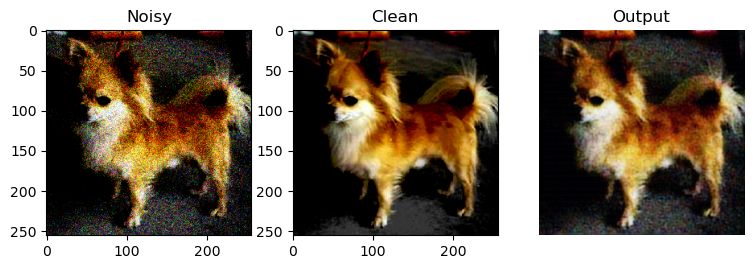

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.8901961].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.10595715..0.88661486].


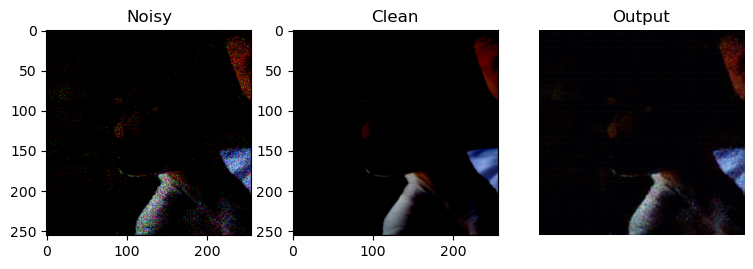

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.27649313..0.9679999].


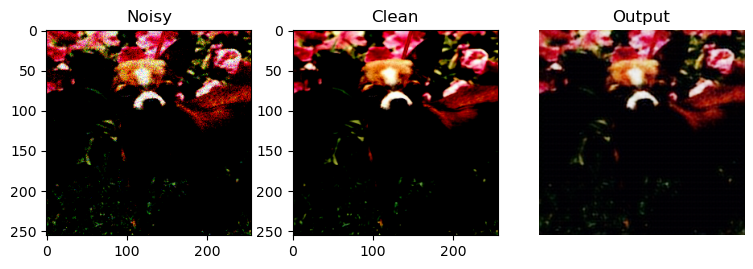

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.23710509..0.954837].


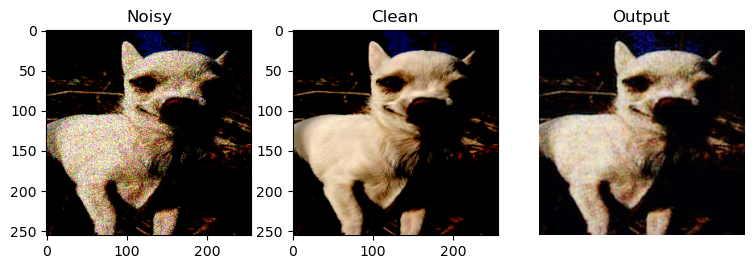

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.27867162..0.9484404].


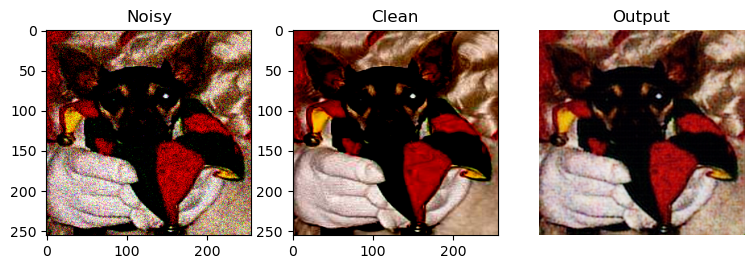

In [33]:
show_denoising_results(model, train_dataloader)
